In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

In [9]:
import pandas as pd

df = pd.read_csv("../Week 1/adult_cleaned.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)
df.head()
df.info()
df.describe()
df.describe(include="object")

print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

Dataset loaded successfully!
Shape: (32537, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32537 entries, 0 to 32536
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32537 non-null  int64 
 1   workclass       32537 non-null  object
 2   fnlwgt          32537 non-null  int64 
 3   education       32537 non-null  object
 4   education_num   32537 non-null  int64 
 5   marital_status  32537 non-null  object
 6   occupation      32537 non-null  object
 7   relationship    32537 non-null  object
 8   race            32537 non-null  object
 9   sex             32537 non-null  object
 10  capital_gain    32537 non-null  int64 
 11  capital_loss    32537 non-null  int64 
 12  hours_per_week  32537 non-null  int64 
 13  native_country  32537 non-null  object
 14  income          32537 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB
Missing values: 0
Duplicate rows: 0


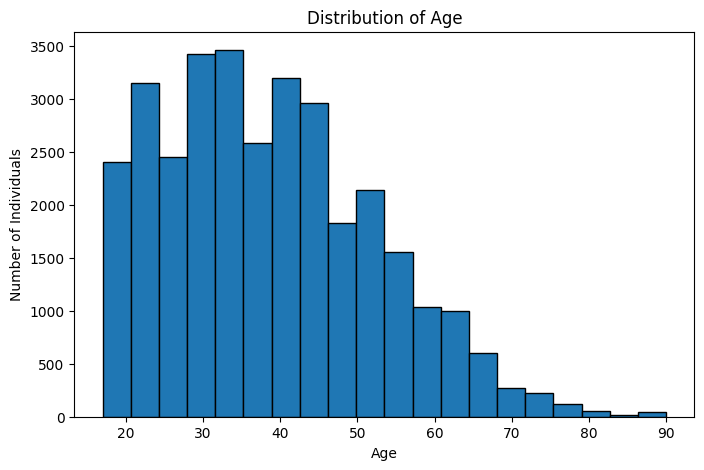

In [10]:
plt.figure(figsize=(8,5))

plt.hist(df["age"], bins=20, edgecolor="black")

plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Number of Individuals")

plt.show()

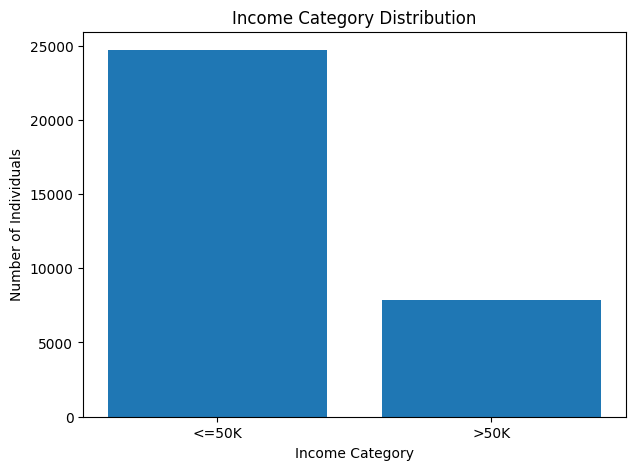

In [11]:
income_counts = df["income"].value_counts()

plt.figure(figsize=(7,5))

plt.bar(income_counts.index, income_counts.values)

plt.title("Income Category Distribution")
plt.xlabel("Income Category")
plt.ylabel("Number of Individuals")

plt.show()

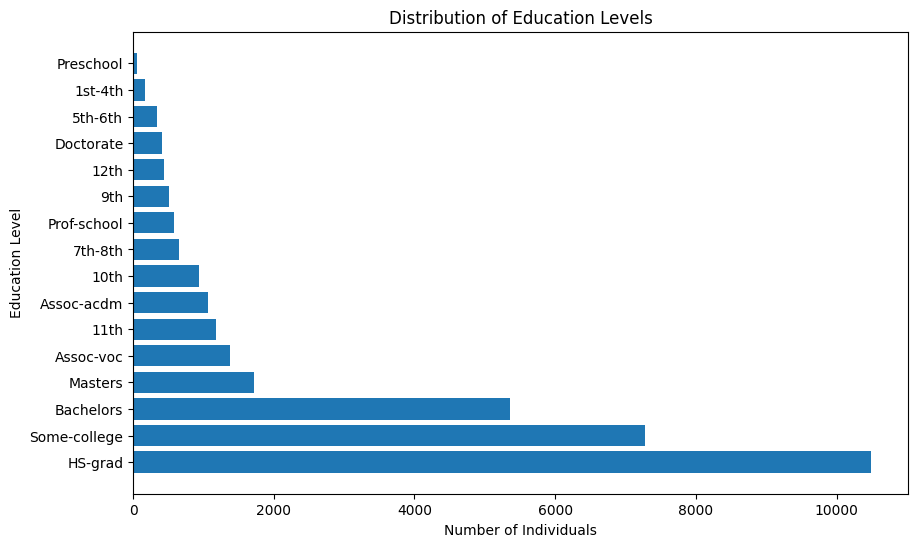

In [12]:
education_counts = df["education"].value_counts()

plt.figure(figsize=(10,6))

plt.barh(education_counts.index, education_counts.values)

plt.title("Distribution of Education Levels")
plt.xlabel("Number of Individuals")
plt.ylabel("Education Level")

plt.show()

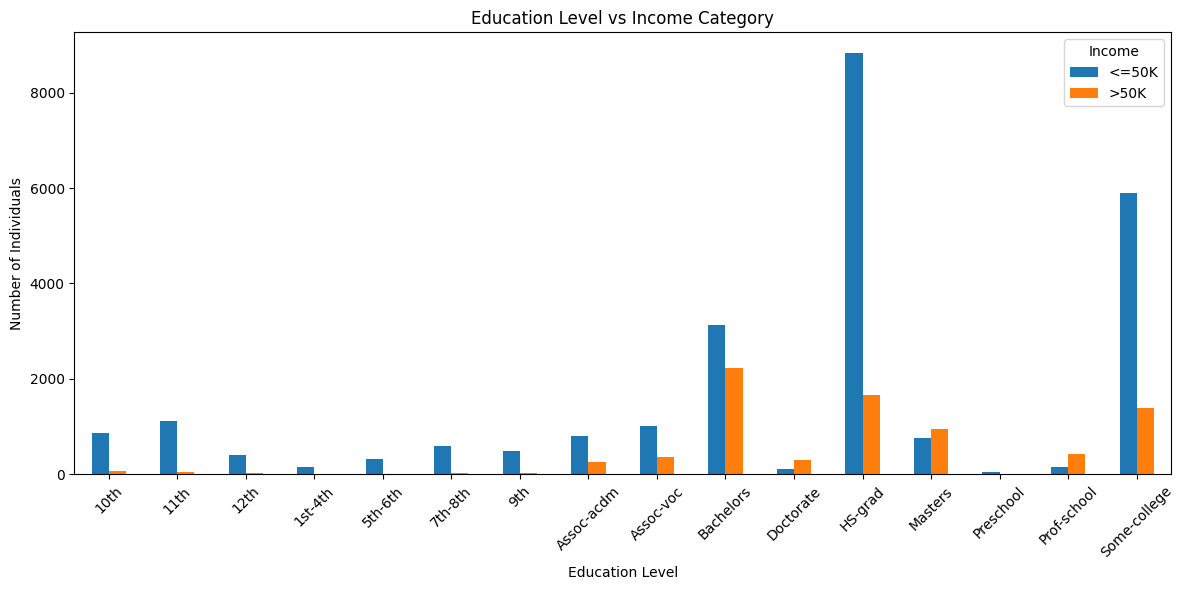

In [13]:
education_income = pd.crosstab(
    df["education"],
    df["income"]
)

education_income.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Education Level vs Income Category")
plt.xlabel("Education Level")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)

plt.legend(title="Income")

plt.tight_layout()
plt.show()

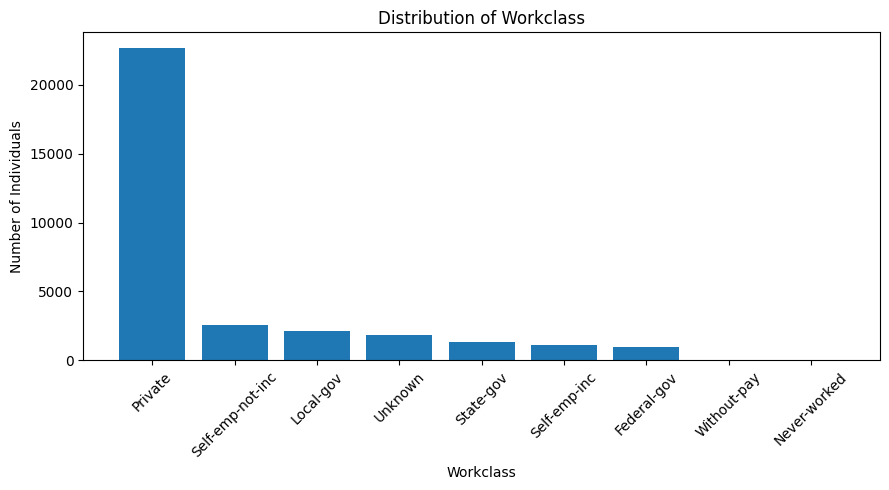

In [14]:
workclass_counts = df["workclass"].value_counts()

plt.figure(figsize=(9,5))

plt.bar(workclass_counts.index, workclass_counts.values)

plt.title("Distribution of Workclass")
plt.xlabel("Workclass")
plt.ylabel("Number of Individuals")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

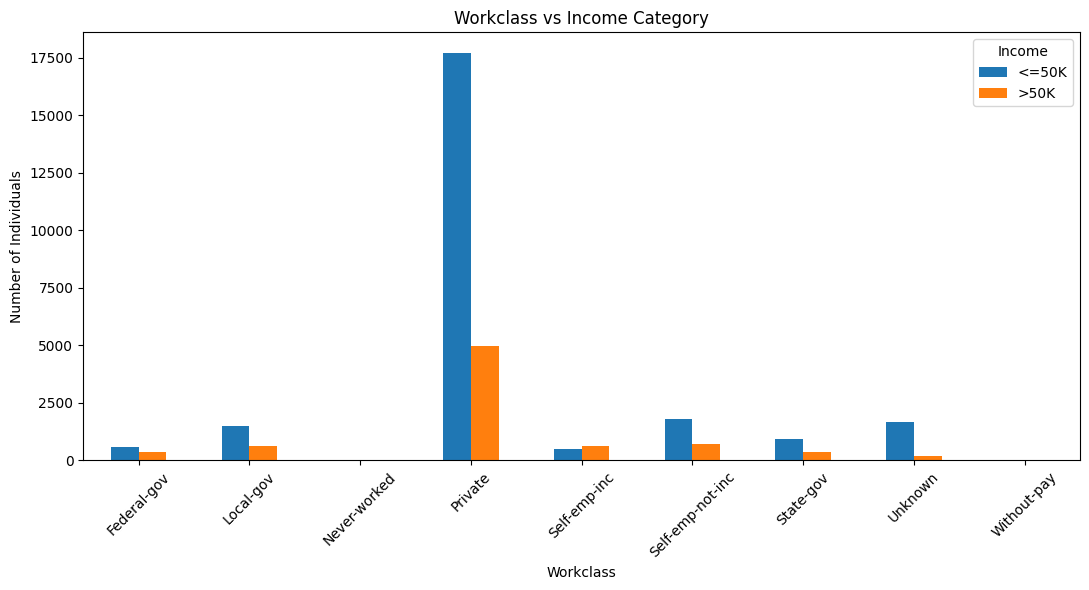

In [15]:
workclass_income = pd.crosstab(
    df["workclass"],
    df["income"]
)

workclass_income.plot(
    kind="bar",
    figsize=(11,6)
)

plt.title("Workclass vs Income Category")
plt.xlabel("Workclass")
plt.ylabel("Number of Individuals")

plt.xticks(rotation=45)
plt.legend(title="Income")

plt.tight_layout()
plt.show()

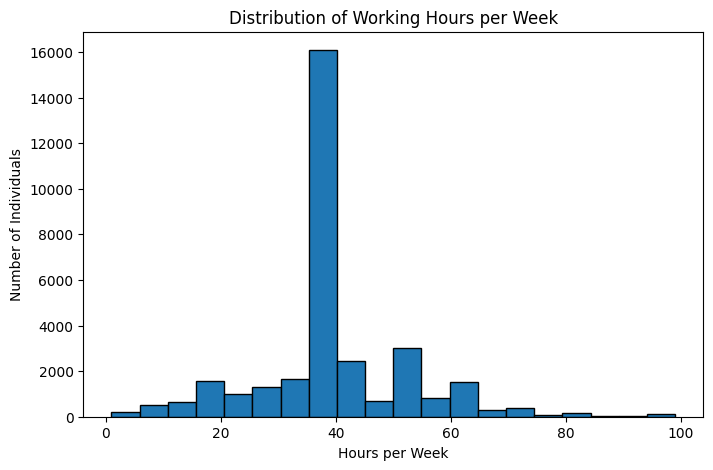

In [16]:
plt.figure(figsize=(8,5))

plt.hist(
    df["hours_per_week"],
    bins=20,
    edgecolor="black"
)

plt.title("Distribution of Working Hours per Week")
plt.xlabel("Hours per Week")
plt.ylabel("Number of Individuals")

plt.show()

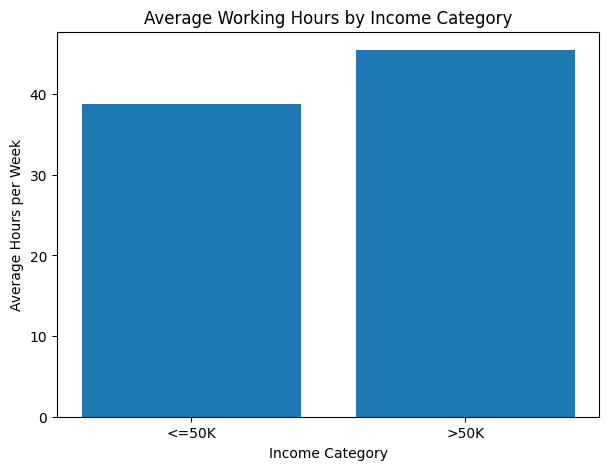

income
<=50K    38.842862
>50K     45.473402
Name: hours_per_week, dtype: float64


In [17]:
income_hours = df.groupby("income")["hours_per_week"].mean()

plt.figure(figsize=(7,5))

plt.bar(income_hours.index, income_hours.values)

plt.title("Average Working Hours by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Average Hours per Week")

plt.show()

print(income_hours)

C:\Users\Rajiv\AppData\Local\Temp\ipykernel_16744\1853685804.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


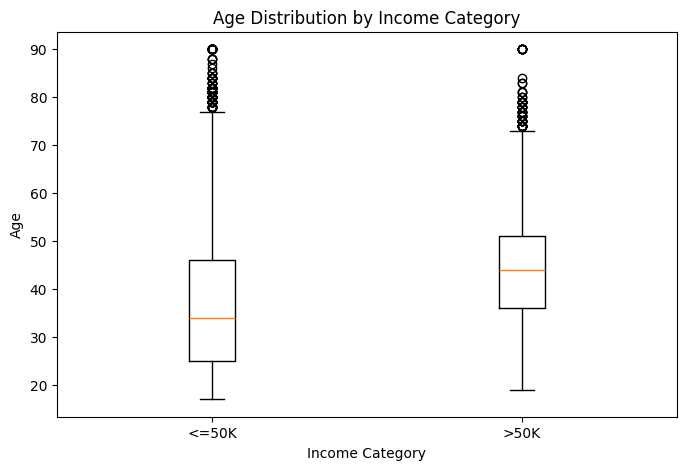

In [18]:
income_groups = [
    df[df["income"] == "<=50K"]["age"],
    df[df["income"] == ">50K"]["age"]
]

plt.figure(figsize=(8,5))

plt.boxplot(
    income_groups,
    labels=["<=50K", ">50K"]
)

plt.title("Age Distribution by Income Category")
plt.xlabel("Income Category")
plt.ylabel("Age")

plt.show()

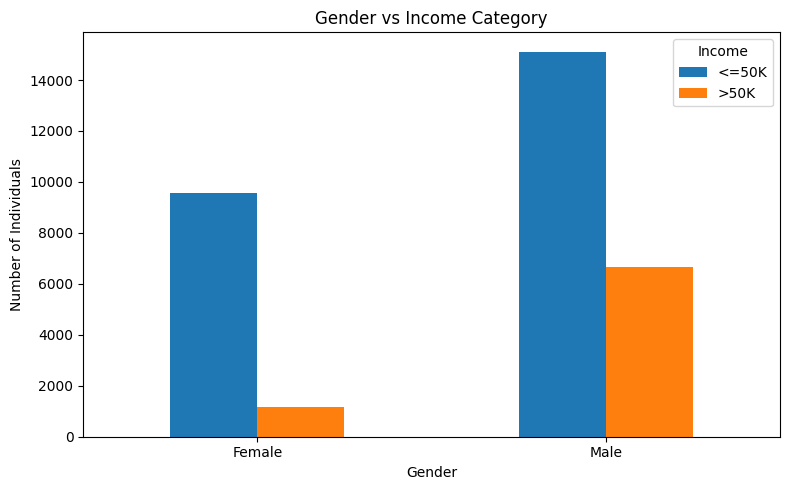

In [19]:
gender_income = pd.crosstab(
    df["sex"],
    df["income"]
)

gender_income.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Gender vs Income Category")
plt.xlabel("Gender")
plt.ylabel("Number of Individuals")

plt.xticks(rotation=0)
plt.legend(title="Income")

plt.tight_layout()
plt.show()

In [20]:
numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

print(correlation_matrix)

                     age    fnlwgt  education_num  capital_gain  capital_loss  \
age             1.000000 -0.076447       0.036224      0.077676      0.057745   
fnlwgt         -0.076447  1.000000      -0.043388      0.000429     -0.010260   
education_num   0.036224 -0.043388       1.000000      0.122664      0.079892   
capital_gain    0.077676  0.000429       0.122664      1.000000     -0.031639   
capital_loss    0.057745 -0.010260       0.079892     -0.031639      1.000000   
hours_per_week  0.068515 -0.018898       0.148422      0.078408      0.054229   

                hours_per_week  
age                   0.068515  
fnlwgt               -0.018898  
education_num         0.148422  
capital_gain          0.078408  
capital_loss          0.054229  
hours_per_week        1.000000  


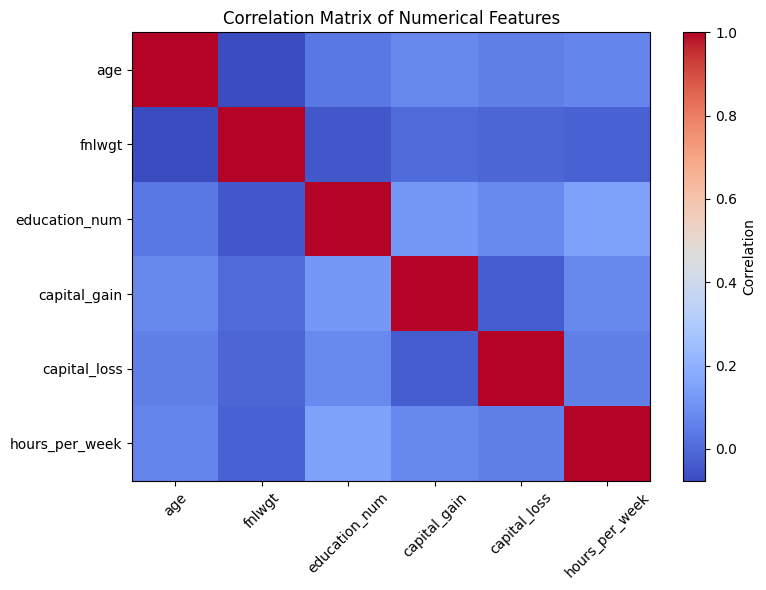

In [21]:
plt.figure(figsize=(8,6))

plt.imshow(
    correlation_matrix,
    cmap="coolwarm",
    aspect="auto"
)

plt.colorbar(label="Correlation")

plt.xticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns,
    rotation=45
)

plt.yticks(
    range(len(correlation_matrix.columns)),
    correlation_matrix.columns
)

plt.title("Correlation Matrix of Numerical Features")

plt.tight_layout()
plt.show()

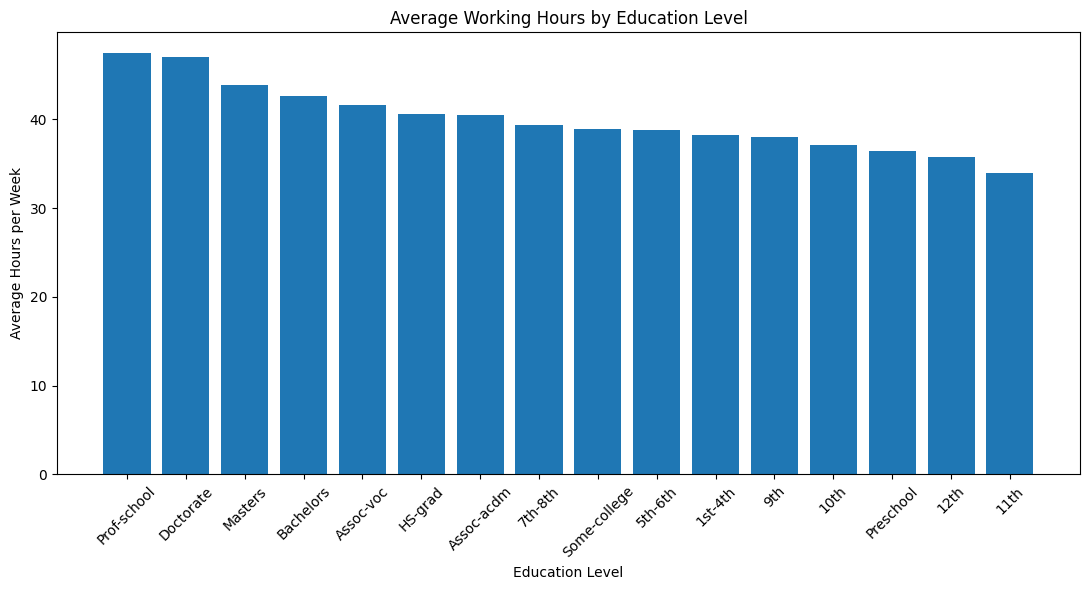

In [22]:
education_hours = (
    df.groupby("education")["hours_per_week"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(11,6))

plt.bar(
    education_hours.index,
    education_hours.values
)

plt.title("Average Working Hours by Education Level")
plt.xlabel("Education Level")
plt.ylabel("Average Hours per Week")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

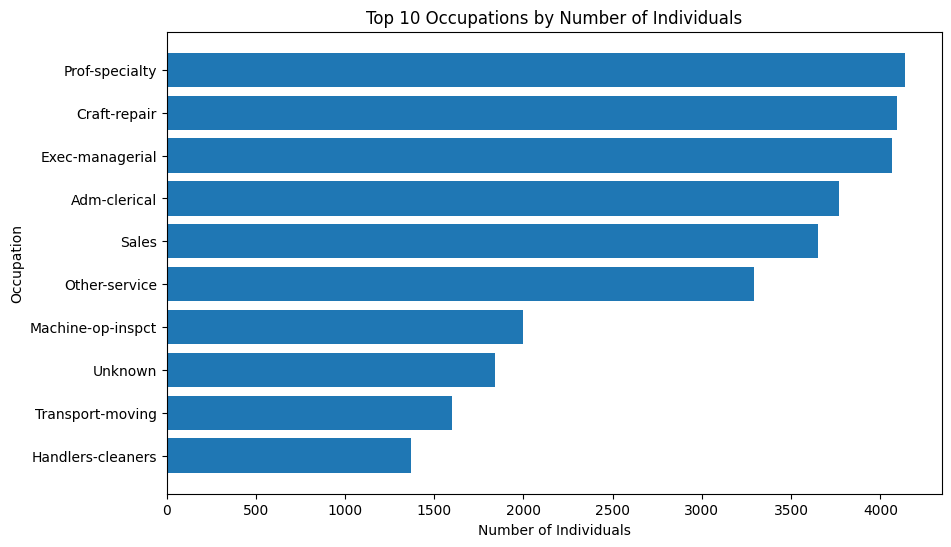

In [23]:
occupation_counts = df["occupation"].value_counts().head(10)

plt.figure(figsize=(10,6))

plt.barh(
    occupation_counts.index[::-1],
    occupation_counts.values[::-1]
)

plt.title("Top 10 Occupations by Number of Individuals")
plt.xlabel("Number of Individuals")
plt.ylabel("Occupation")

plt.show()

In [24]:
print("EDA SUMMARY")
print("=" * 40)

print("\nAverage age:", round(df["age"].mean(), 2))
print("Average working hours:", round(df["hours_per_week"].mean(), 2))

print("\nMost common education:")
print(df["education"].mode()[0])

print("\nMost common occupation:")
print(df["occupation"].mode()[0])

print("\nMost common workclass:")
print(df["workclass"].mode()[0])

print("\nIncome distribution:")
print(df["income"].value_counts())

print("\nAverage hours by income:")
print(df.groupby("income")["hours_per_week"].mean())

EDA SUMMARY

Average age: 38.59
Average working hours: 40.44

Most common education:
HS-grad

Most common occupation:
Prof-specialty

Most common workclass:
Private

Income distribution:
income
<=50K    24698
>50K      7839
Name: count, dtype: int64

Average hours by income:
income
<=50K    38.842862
>50K     45.473402
Name: hours_per_week, dtype: float64


In [25]:
print("FINAL EDA DATASET")
print("=" * 40)
print("Shape:", df.shape)
print("Missing values:", df.isnull().sum().sum())
print("Duplicates:", df.duplicated().sum())

FINAL EDA DATASET
Shape: (32537, 15)
Missing values: 0
Duplicates: 0
